# Depth scaling

How does runtime change with L?

B=2, T=128, D=128, H=4, V=50257. [FLOPs calculation](README.md).
The notebook reads saved results, without running the model.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

B, T, D, H, V = 2, 128, 128, 4, 50257

F_block = 24 * B * T * D**2 + 4 * B * T**2 * D
F_head = 2 * B * T * D * V

accounting = pd.DataFrame({"L": [1, 2, 4, 8, 12, 16]})

accounting["block_flops"] = accounting["L"] * F_block
accounting["head_flops"] = F_head
accounting["forward_flops"] = accounting["block_flops"] + F_head
accounting["forward_gflops"] = accounting["forward_flops"] / 1e9
accounting["block_fraction"] = (
    accounting["block_flops"] / accounting["forward_flops"]
)
accounting["relative_to_L2"] = (
    accounting["forward_flops"] / (2 * F_block + F_head)
)

accounting

,L,block_flops,head_flops,forward_flops,forward_gflops,block_fraction,relative_to_L2
0,1,117440512,3293642752,3411083264,3.411083,0.034429,0.966717
1,2,234881024,3293642752,3528523776,3.528524,0.066566,1.000000
2,4,469762048,3293642752,3763404800,3.763405,0.124824,1.066566
3,8,939524096,3293642752,4233166848,4.233167,0.221944,1.199699
4,12,1409286144,3293642752,4702928896,4.702929,0.299661,1.332832
5,16,1879048192,3293642752,5172690944,5.172691,0.363263,1.465965


## Depth sweep

Three repeats. Relative times use L=2 from the same repeat.
The dashed line shows relative matmul FLOPs, without the AdamW update.

In [2]:
root = Path.cwd()
if root.name == "01_depth_scaling":
    root = root.parent.parent

results_dir = root / "experiments/01_depth_scaling/results"
workloads = ["forward", "forward_backward", "optimizer_step"]
depth_rows = []

for repeat in ["repeat-01", "repeat-02", "repeat-03"]:
    for L in accounting["L"]:
        path = results_dir / repeat / f"l{L}.json"
        with path.open() as file:
            result = json.load(file)

        for workload, measurement in result["measurements"].items():
            depth_rows.append({
                "repeat": repeat, "L": L, "workload": workload,
                "parameters": result["parameter_count"],
                "mean_ms": measurement["mean_seconds"] * 1000,
                "median_ms": measurement["median_seconds"] * 1000,
                "tokens_per_second": measurement["tokens_per_second"],
            })

depth = pd.DataFrame(depth_rows).sort_values(["repeat", "L", "workload"])
depth.pivot(index=["repeat", "L"], columns="workload",
            values=["parameters", "mean_ms", "median_ms", "tokens_per_second"]).round(2)


parameters                   ... tokens_per_second               
workload        forward forward_backward  ...  forward_backward optimizer_step
repeat    L                               ...                                 
repeat-01 1   6664192.0        6664192.0  ...           9298.10        7148.53
          2   6862464.0        6862464.0  ...           8890.54        6948.53
          4   7259008.0        7259008.0  ...           8432.60        6493.14
          8   8052096.0        8052096.0  ...           7479.60        5596.10
          12  8845184.0        8845184.0  ...           6676.21        4596.23
          16  9638272.0        9638272.0  ...           5942.52        3721.69
repeat-02 1   6664192.0        6664192.0  ...           9295.57        7160.68
          2   6862464.0        6862464.0  ...           8903.72        6952.61
          4   7259008.0        7259008.0  ...           8457.67        6436.34
          8   8052096.0        8052096.0  ...           7481.66        5555.00
          12  8845184.0        8845184.0  ...           6765.06        4656.40
          16  9638272.0        9638272.0  ...           5946.31        3697.99
repeat-03 1   6664192.0        6664192.0  ...           9251.00        7179.23
          2   6862464.0        6862464.0  ...           8751.49        6965.58
          4   7259008.0        7259008.0  ...           8460.59        6450.71
          8   8052096.0        8052096.0  ...           7435.22        5571.78
          12  8845184.0        8845184.0  ...           6674.07        4640.22
          16  9638272.0        9638272.0  ...           5936.62        3579.67

[18 rows x 12 columns]

In [3]:
comparison = depth.merge(
    accounting[["L", "forward_flops", "relative_to_L2"]], on="L"
)
baseline = depth[depth["L"] == 2][["repeat", "workload", "mean_ms", "median_ms"]]
comparison = comparison.merge(
    baseline, on=["repeat", "workload"], suffixes=("", "_L2")
)
comparison["mean_relative"] = comparison["mean_ms"] / comparison["mean_ms_L2"]
comparison["median_relative"] = comparison["median_ms"] / comparison["median_ms_L2"]

relative_columns = ["relative_to_L2", "mean_relative", "median_relative"]

comparison[["repeat", "L", "workload", "parameters", "forward_flops",
            "mean_ms", "median_ms", "tokens_per_second", *relative_columns]].round(3)


,repeat,L,workload,parameters,forward_flops,mean_ms,median_ms,tokens_per_second,relative_to_L2,mean_relative,median_relative
0,repeat-01,1,forward,6664192,3411083264,10.105,9.756,25333.803,0.967,0.570,0.548
1,repeat-01,1,forward_backward,6664192,3411083264,27.533,27.700,9298.098,0.967,0.956,0.968
2,repeat-01,1,optimizer_step,6664192,3411083264,35.812,35.656,7148.533,0.967,0.972,0.970
3,repeat-01,2,forward,6862464,3528523776,17.738,17.805,14432.307,1.000,1.000,1.000
4,repeat-01,2,forward_backward,6862464,3528523776,28.795,28.619,8890.539,1.000,1.000,1.000
5,repeat-01,2,optimizer_step,6862464,3528523776,36.842,36.768,6948.530,1.000,1.000,1.000
6,repeat-01,4,forward,7259008,3763404800,18.526,18.687,13818.500,1.067,1.044,1.050
7,repeat-01,4,forward_backward,7259008,3763404800,30.358,30.096,8432.602,1.067,1.054,1.052
8,repeat-01,4,optimizer_step,7259008,3763404800,39.426,39.428,6493.138,1.067,1.070,1.072
9,repeat-01,8,forward,8052096,4233166848,15.737,15.928,16267.066,1.200,0.887,0.895


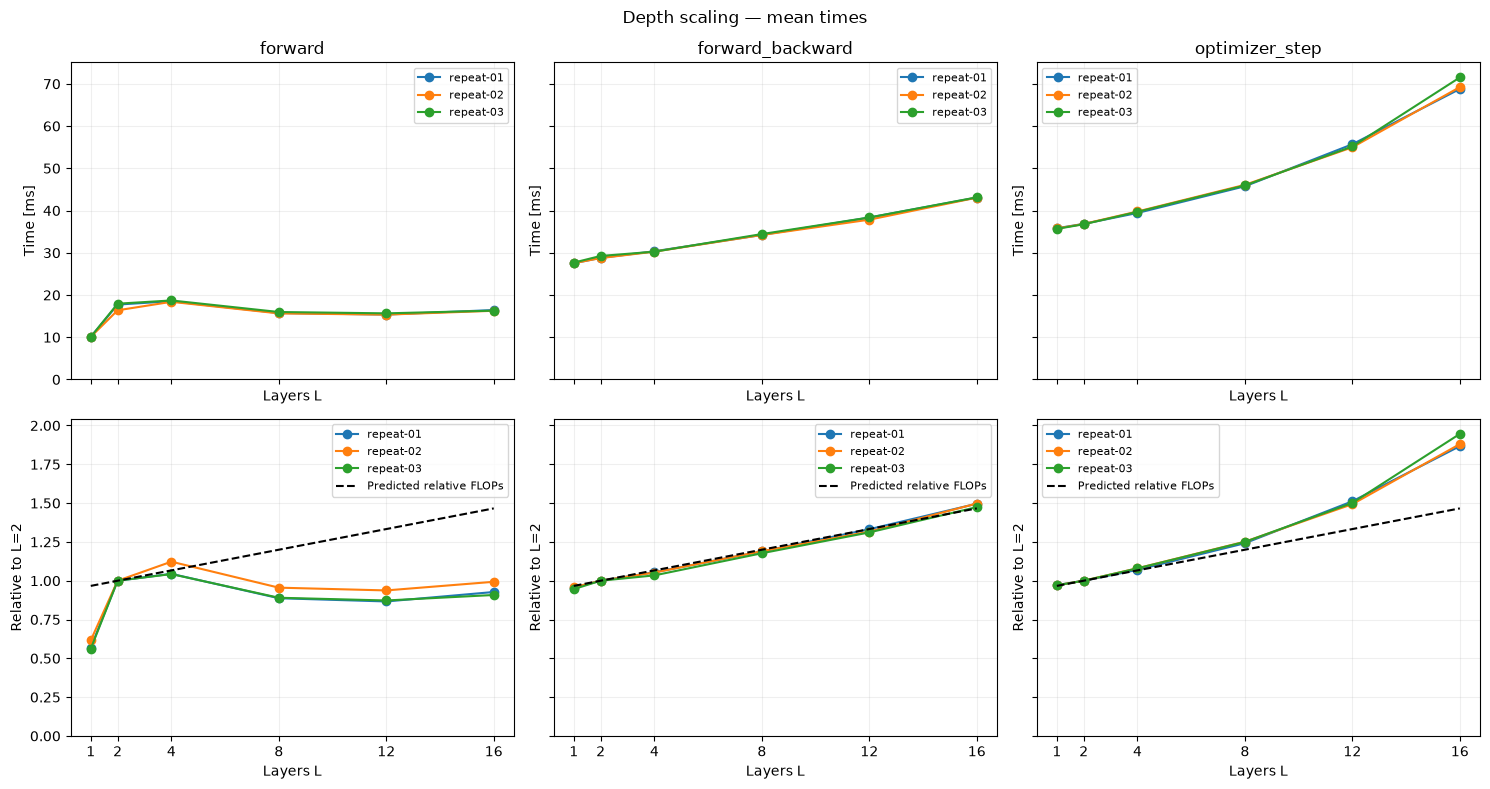

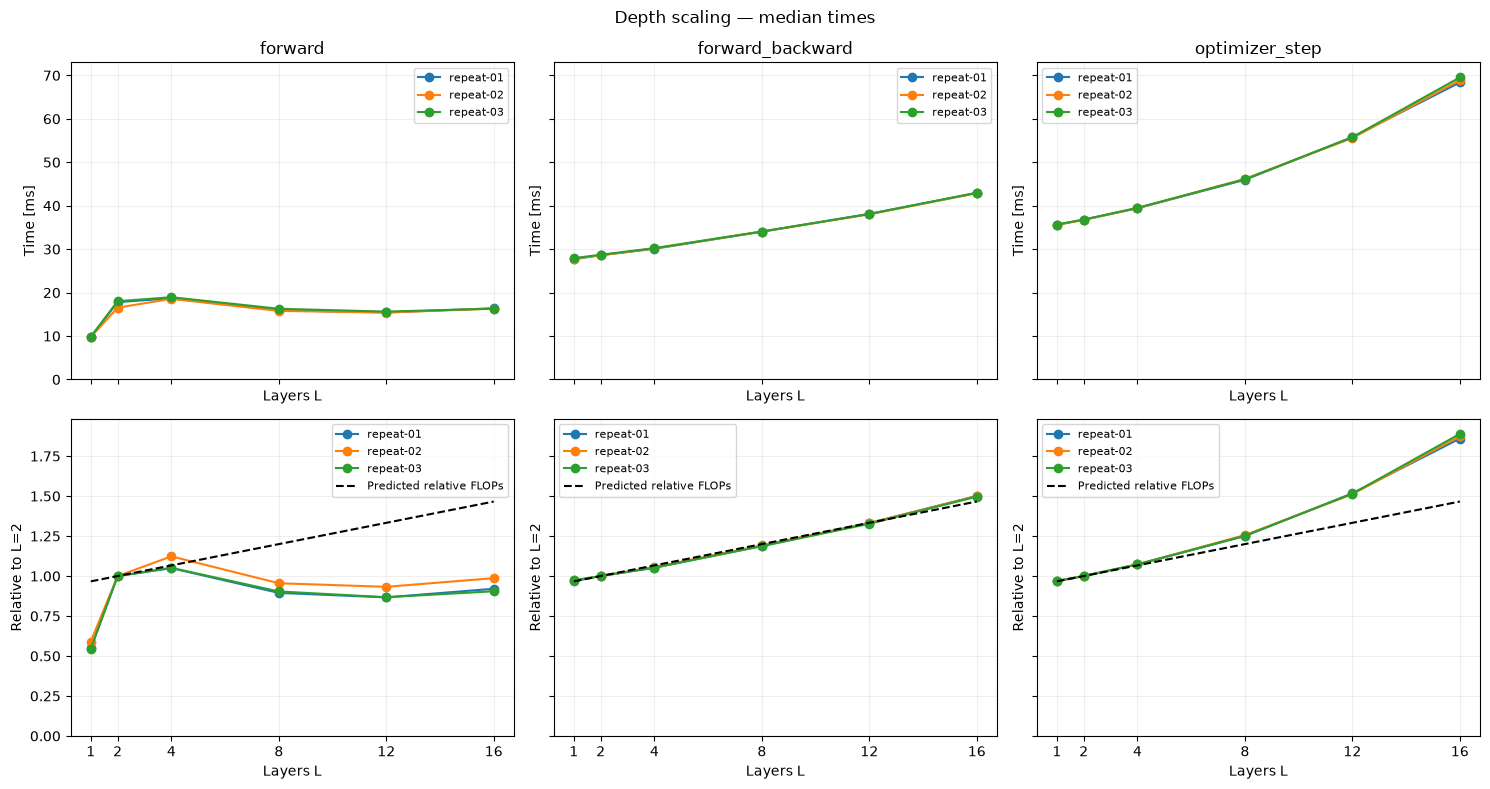

In [4]:
figures_dir = results_dir.parent / "figures"
figures_dir.mkdir(exist_ok=True)

for statistic in ["mean", "median"]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey="row")
    for col, workload in enumerate(workloads):
        data = comparison[comparison["workload"] == workload]
        for repeat, points in data.groupby("repeat"):
            points = points.sort_values("L")
            axes[0, col].plot(points["L"], points[f"{statistic}_ms"], "o-", label=repeat)
            axes[1, col].plot(points["L"], points[f"{statistic}_relative"], "o-", label=repeat)
        axes[1, col].plot(accounting["L"], accounting["relative_to_L2"],
                          "k--", label="Predicted relative FLOPs")
        axes[0, col].set_title(workload)
        axes[0, col].set_ylabel("Time [ms]")
        axes[1, col].set_ylabel("Relative to L=2")
        for ax in axes[:, col]:
            ax.set_xlabel("Layers L")
            ax.set_xticks(accounting["L"])
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8)
    axes[0, 0].set_ylim(0, comparison[f"{statistic}_ms"].max() * 1.05)
    axes[1, 0].set_ylim(0, max(comparison[f"{statistic}_relative"].max(),
                              accounting["relative_to_L2"].max()) * 1.05)
    fig.suptitle(f"Depth scaling — {statistic} times")
    fig.tight_layout()
    fig.savefig(figures_dir / f"depth_{statistic}.png", dpi=150, bbox_inches="tight")
    plt.show()


## Earlier checks: autograd on/off

Separate L=2 runs, not part of the depth sweep.

In [5]:
groups = {"Baseline": "check-*", "Autograd on": "grad-check-*", "Autograd off": "no-grad-check-*"}
runs, rows = {}, []

for group, pattern in groups.items():
    runs[group] = {}
    for path in sorted(results_dir.glob(f"{pattern}/l2.json")):
        with path.open() as file:
            result = json.load(file)
        runs[group][path.parent.name] = result
        for workload, measurement in result["measurements"].items():
            rows.append({
                "group": group, "run": path.parent.name, "workload": workload,
                "mean_ms": measurement["mean_seconds"] * 1000,
                "median_ms": measurement["median_seconds"] * 1000,
                "max_ms": max(measurement["samples_seconds"]) * 1000,
            })

timings = pd.DataFrame(rows)
timings.round(2)

,group,run,workload,mean_ms,median_ms,max_ms
0,Baseline,check-01,forward,15.55,16.27,24.67
1,Baseline,check-01,forward_backward,28.39,28.35,37.52
2,Baseline,check-01,optimizer_step,36.43,36.51,49.17
3,Baseline,check-02,forward,17.48,17.70,25.35
4,Baseline,check-02,forward_backward,28.51,28.50,34.55
5,Baseline,check-02,optimizer_step,36.51,36.54,51.52
6,Baseline,check-03,forward,16.31,16.95,23.35
7,Baseline,check-03,forward_backward,28.43,28.39,41.43
8,Baseline,check-03,optimizer_step,36.50,36.58,49.40
9,Autograd on,grad-check-01,forward,18.87,17.52,170.28


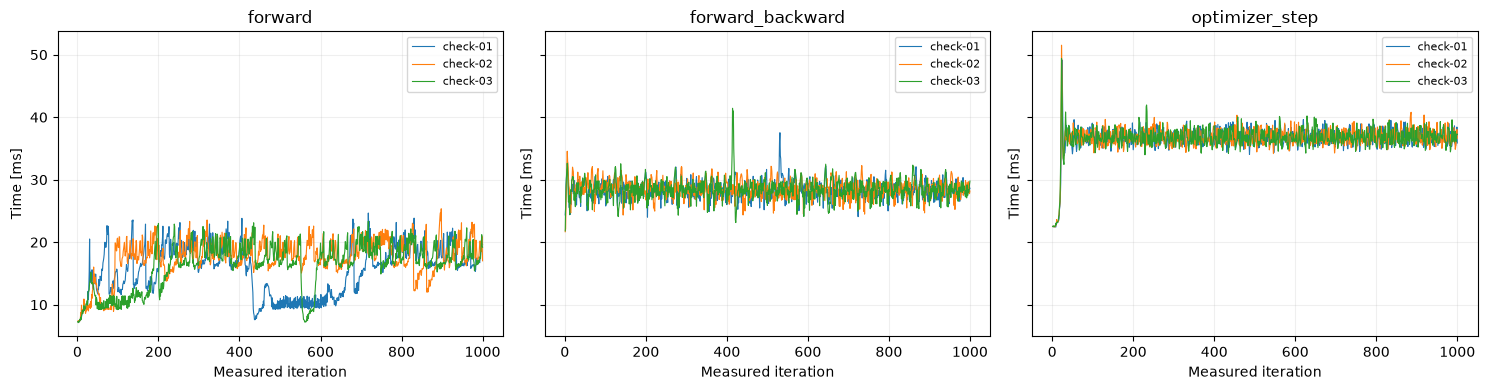

In [6]:
workloads = ["forward", "forward_backward", "optimizer_step"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, workload in zip(axes, workloads):
    for name, result in runs["Baseline"].items():
        ms = [s * 1000 for s in result["measurements"][workload]["samples_seconds"]]
        ax.plot(range(1, len(ms) + 1), ms, label=name, linewidth=0.8)
    ax.set_title(workload)
    ax.set_xlabel("Measured iteration")
    ax.set_ylabel("Time [ms]")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

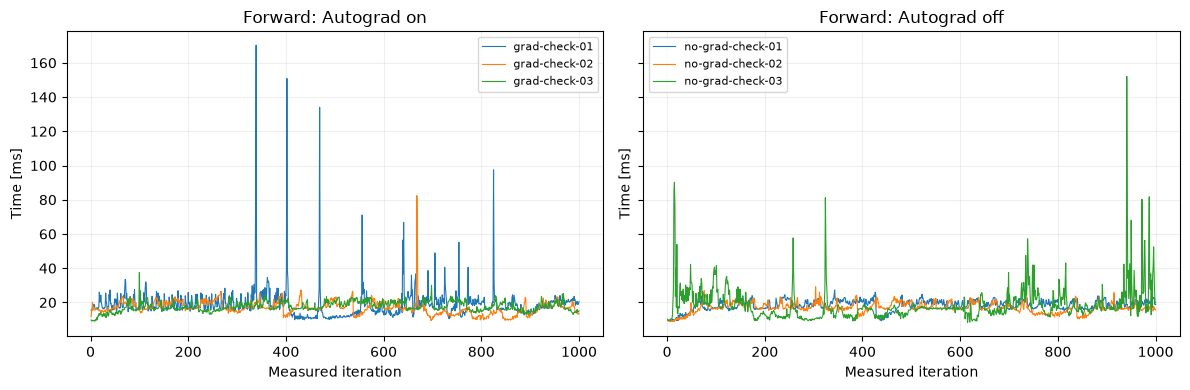

In [7]:
zoom = False  # True zooms to 0–40 ms; saved samples are never filtered.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, group in zip(axes, ["Autograd on", "Autograd off"]):
    for name, result in runs[group].items():
        ms = [s * 1000 for s in result["measurements"]["forward"]["samples_seconds"]]
        ax.plot(range(1, len(ms) + 1), ms, label=name, linewidth=0.8)
    ax.set_title(f"Forward: {group}")
    ax.set_xlabel("Measured iteration")
    ax.set_ylabel("Time [ms]")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
    if zoom:
        ax.set_ylim(0, 40)

plt.tight_layout()
plt.show()

## Memory across steps

FP32 tensor sizes, with N shared parameters counted once:

$$
M_{\text{weights}}=4N,\quad M_{\text{gradients}}\approx4N,\quad M_{\text{Adam}}\approx8N
$$

$$
M_{\text{logits}}=4BTV
$$

Activations and temporary tensors add more memory.
`tensor_MiB` counts live tensors; `driver_MiB` also includes cache. Don't add the counters together. MiB = bytes / 2^20.

We clear gradients before forward. Backward creates them; the first AdamW step creates optimizer states. `after_release` drops logits/loss, not gradients.
These are snapshots after each stage, not peaks.

In [8]:
memory_rows = []
memory_runs = {}
for path in sorted((results_dir / "memory-history").glob("*.json")):
    with path.open() as file:
        result = json.load(file)
    memory_runs[path.stem] = result
    for snapshot in result["snapshots"]:
        memory_rows.append({
            "workload": path.stem, "step": snapshot["step"], "stage": snapshot["stage"],
            "tensor_MiB": snapshot["tensor_bytes"] / 2**20,
            "driver_MiB": snapshot["driver_bytes"] / 2**20,
        })

memory = pd.DataFrame(memory_rows)
memory[memory["step"] > 0].groupby(["workload", "stage"], sort=False)[
    ["tensor_MiB", "driver_MiB"]
].agg(["first", "last", "min", "max"]).round(2)

tensor_MiB          ... driver_MiB         
                                           first    last  ...        min      max
workload         stage                                    ...                    
forward-no-grad  before_forward            27.14   27.14  ...    1032.47  1034.72
                 after_forward             77.14   77.14  ...    1034.70  1034.72
                 after_release             27.14   27.14  ...    1034.70  1034.72
forward          before_forward            27.14   27.14  ...    1032.47  1034.72
                 after_forward            132.44  132.44  ...    1034.70  1034.72
                 after_release             27.14   27.14  ...    1034.70  1034.72
forward_backward before_forward            27.14   27.14  ...    1032.47  1092.81
                 after_forward            132.44  132.44  ...    1034.72  1092.81
                 after_backward           103.78  103.78  ...    1092.80  1092.81
                 after_release             53.78   53.78  ...    1092.80  1092.81
optimizer_step   before_forward            27.14   80.42  ...    1032.47  1100.80
                 after_forward            132.44  185.71  ...    1034.70  1100.80
                 after_backward           103.78  157.06  ...    1092.80  1100.80
                 after_optimizer_step     157.06  157.06  ...    1100.80  1100.80
                 after_release            107.06  107.06  ...    1100.80  1100.80

[15 rows x 8 columns]

In [9]:
result = memory_runs["optimizer_step"]
N = result["parameter_count"]
c = result["config"]
B, T, V = c["batch_size"], c["sequence_length"], c["model"]["vocab_size"]

payloads = pd.DataFrame({
    "part": ["Weights", "Gradients", "Two Adam moments", "Logits", "Model buffers"],
    "bytes": [4 * N, 4 * N, 8 * N, 4 * B * T * V, result["buffer_bytes"]],
})
payloads["MiB"] = payloads["bytes"] / 2**20
payloads.round(2)

,part,bytes,MiB
0,Weights,27449856,26.18
1,Gradients,27449856,26.18
2,Two Adam moments,54899712,52.36
3,Logits,51463168,49.08
4,Model buffers,524288,0.50


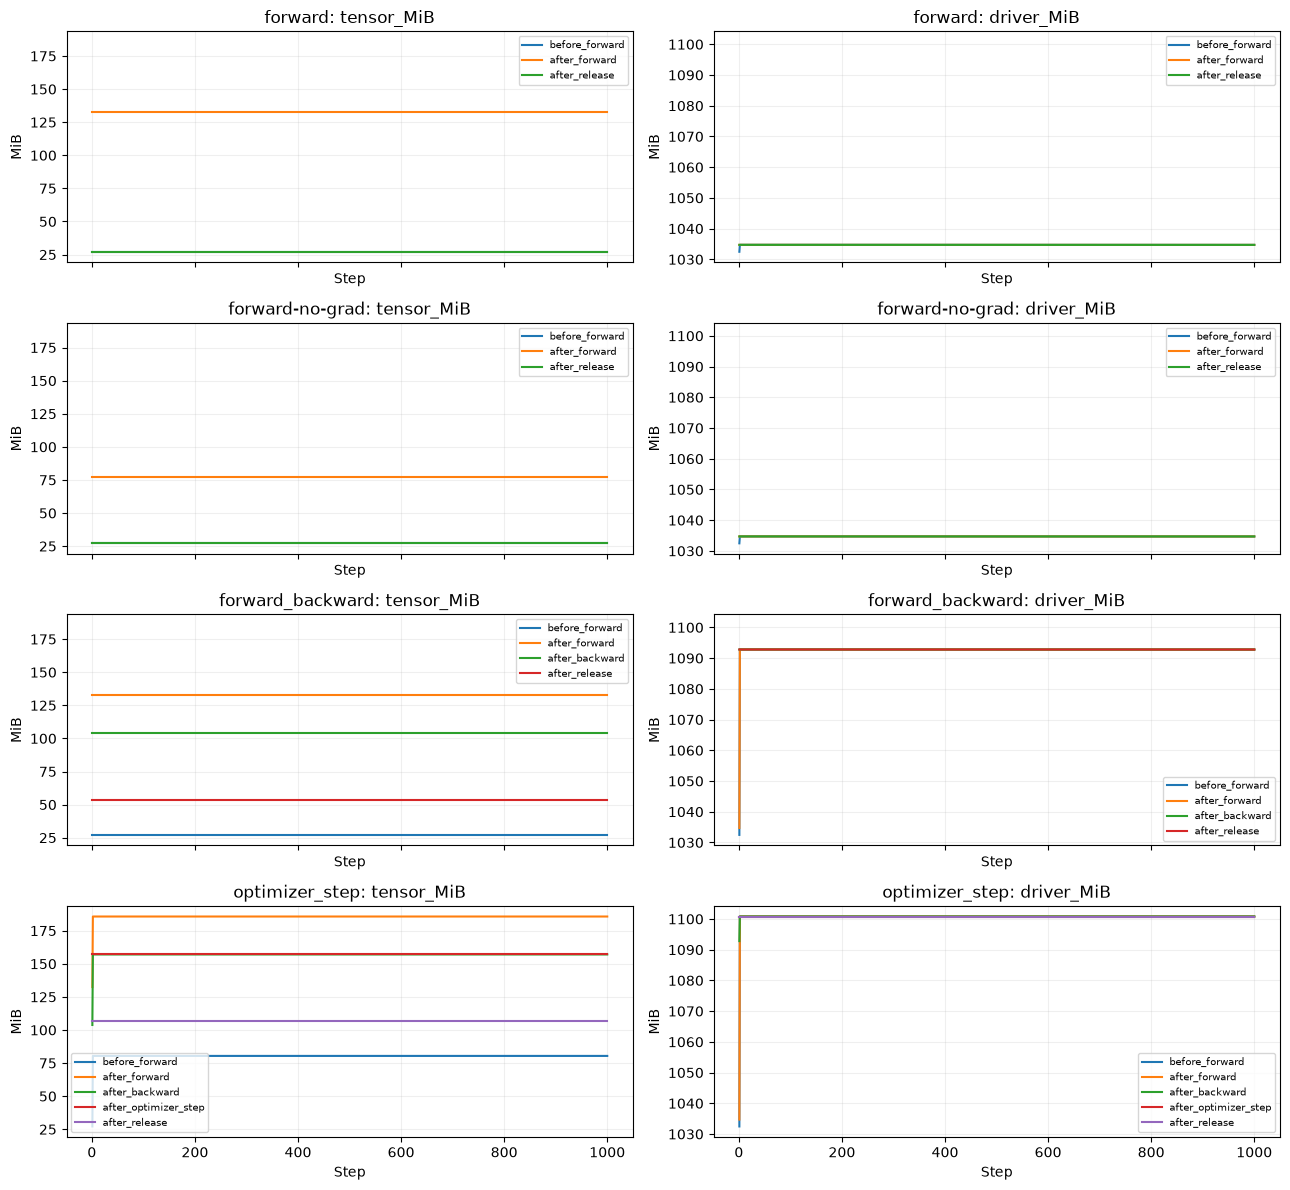

In [10]:
last_step = 1000  # Set 20 to inspect the first steps.
names = ["forward", "forward-no-grad", "forward_backward", "optimizer_step"]
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True, sharey="col")

for row, name in enumerate(names):
    data = memory[(memory["workload"] == name) & (memory["step"] > 0)]
    data = data[data["step"] <= last_step]
    for col, metric in enumerate(["tensor_MiB", "driver_MiB"]):
        ax = axes[row, col]
        for stage, points in data.groupby("stage", sort=False):
            ax.plot(points["step"], points[metric], label=stage)
        ax.set_title(f"{name}: {metric}")
        ax.set_xlabel("Step")
        ax.set_ylabel("MiB")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()